**Protein mutation ML**

In [ ]:
# Standard imports
import pandas as pd
import numpy as np

# Special imports
import mavenn

In [ ]:
data = mavenn.load_example_dataset('gb1')

In [ ]:
seq = data['x']
f_score = data['y']
final = np.column_stack([seq, f_score])
df = pd.DataFrame({'sequence': seq, 'score': f_score})
df.to_csv("mavenn_seq_and_scores.csv", index=False)

In [ ]:
print(final)

In [ ]:
max_val = np.max(final[:, 1])
min_val = np.min(final[:, 1])
print(max_val, min_val)

In [ ]:
# Load your MAVE-NN data
df = pd.read_csv("mavenn_seq_and_scores.csv") 

# Define your bins
bins = [-12, -4, -1, 1, 4]
labels = ['unstable', 'mid-range', 'stable', 'enhanced']
df['category'] = pd.cut(df['score'], bins=bins, labels=labels)
# print(type(df))
# print(df['category'])
# Sample 12-13 sequences from each category to hit ~50 total
selected_50 = df.groupby('category').apply(lambda x: x.sample(n=min(len(x), 13), random_state=42))
# print(type(selected_50))
selected_50.to_csv("candidates_for_sim.csv")


In [ ]:
df_new = pd.read_csv("candidates_for_sim.csv")

for index, row in df_new.iterrows():
    print(row['sequence'], row['score'])

**Single mutant fitness score (from Nisthal et al. 2019)**

In [3]:
import numpy as np
import pandas as pd
import mavenn

data_df = mavenn.load_example_dataset('nisthal')

print(data_df.shape)
data_df.head()

(813, 3)


,x,name,y
0,AYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,T02A,0.4704
1,DYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,T02D,0.5538
2,EYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,T02E,-0.1299
3,FYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,T02F,-0.3008
4,GYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,T02G,0.6680


In [8]:
data_df.columns
data_df = data_df[(data_df['y'] > -3) & (data_df['y'] < 3)]

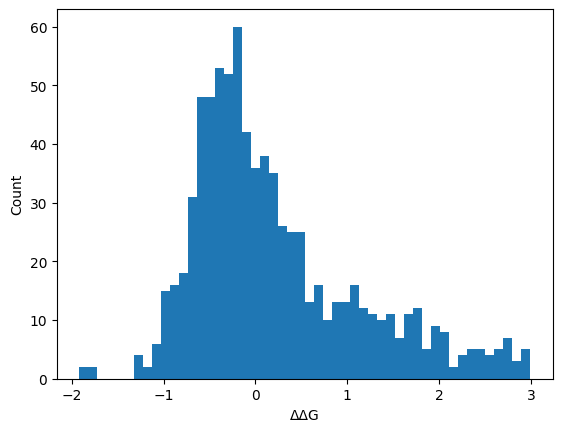

In [9]:
import matplotlib.pyplot as plt

plt.hist(data_df['y'], bins=50)
plt.xlabel('ΔΔG')
plt.ylabel('Count')
plt.show()

In [13]:
stable = data_df[data_df['y'] > 0.5]
neutral = data_df[(data_df['y'] >= -0.5) & (data_df['y'] <= 0.5)]
unstable = data_df[data_df['y'] < -0.5]

In [14]:
subset_df = pd.concat([
    stable.sample(15, random_state=42),
    neutral.sample(20, random_state=42),
    unstable.sample(15, random_state=42)
])

In [15]:
import re

def get_position(name):
    return int(re.findall(r'\d+', name)[0])

data_df['pos'] = data_df['name'].apply(get_position)

In [16]:
data_df['pos'].value_counts()

pos
2     17
8     17
9     17
10    17
11    17
12    17
13    17
14    17
15    17
16    17
17    17
19    17
21    17
22    17
25    17
28    17
29    17
32    17
36    17
38    17
42    17
47    17
56    17
48    17
24    17
23    17
4     16
18    16
35    16
37    16
40    16
44    16
46    16
49    16
50    16
55    16
20    16
6     15
27    15
39    15
53    15
7     14
33    14
51    14
34    14
31    13
54    11
5      8
45     8
41     7
52     7
30     6
3      5
26     2
Name: count, dtype: int64

In [17]:
selected = []

for pos, group in data_df.groupby('pos'):
    
    # split by stability inside each position
    stable = group[group['y'] > 0.5]
    neutral = group[(group['y'] >= -0.5) & (group['y'] <= 0.5)]
    unstable = group[group['y'] < -0.5]
    
    # pick max 1 from each category if available
    if len(stable) > 0:
        selected.append(stable.sample(1))
    if len(neutral) > 0:
        selected.append(neutral.sample(1))
    if len(unstable) > 0:
        selected.append(unstable.sample(1))

In [20]:
subset_df = pd.concat(selected)
subset_df = subset_df.sample(50, random_state=42)
subset_df['pos'].value_counts()

pos
41    2
6     2
12    2
27    2
18    2
30    2
8     2
51    2
16    2
36    1
25    1
26    1
47    1
42    1
29    1
34    1
13    1
17    1
9     1
35    1
22    1
44    1
3     1
45    1
15    1
56    1
5     1
20    1
52    1
32    1
55    1
54    1
2     1
40    1
11    1
24    1
50    1
38    1
7     1
48    1
10    1
Name: count, dtype: int64

In [21]:
subset_df = (
    data_df
    .sort_values('y')  # optional: prioritize diversity in stability
    .groupby('pos', group_keys=False)
    .head(1)
    .sample(50, random_state=42)
)

In [22]:
subset_df['pos'].value_counts()

pos
28    1
34    1
20    1
56    1
9     1
42    1
15    1
51    1
2     1
29    1
37    1
4     1
23    1
50    1
32    1
14    1
44    1
40    1
33    1
22    1
45    1
8     1
13    1
19    1
10    1
48    1
18    1
35    1
27    1
49    1
24    1
17    1
46    1
5     1
53    1
16    1
47    1
12    1
31    1
6     1
41    1
25    1
55    1
36    1
3     1
30    1
26    1
39    1
21    1
54    1
Name: count, dtype: int64

In [23]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

CUDA available: True
Device: NVIDIA GeForce RTX 4070 Ti


In [24]:
from transformers import AutoTokenizer, AutoModel
import torch

device = torch.device("cuda")

tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t33_650M_UR50D")
model = AutoModel.from_pretrained("facebook/esm2_t33_650M_UR50D")

model = model.to(device)
model.eval()
torch.set_grad_enabled(False)

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/534 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [25]:
print(type(model))

<class 'transformers.models.esm.modeling_esm.EsmModel'>


In [26]:
sequences = subset_df['x'].tolist()
len(sequences)

50

In [27]:
def get_embeddings_batch(sequences, batch_size=8):
    all_embeddings = []

    for i in range(0, len(sequences), batch_size):
        batch = sequences[i:i+batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        hidden = outputs.last_hidden_state  # (B, L, d)

        # mean pooling
        embeddings = hidden.mean(dim=1)  # (B, d)

        all_embeddings.append(embeddings.cpu())

    return torch.cat(all_embeddings, dim=0)

In [28]:
X = get_embeddings_batch(sequences, batch_size=8)
print(X.shape)

torch.Size([50, 1280])


In [29]:
X = X.numpy()
y = subset_df['y'].values

In [30]:
np.isnan(X).any()

np.False_

In [31]:
corr = np.corrcoef(X[:, 0], y)[0, 1]
print("Sample correlation:", corr)

Sample correlation: 0.22025823336673334


In [32]:
print(X.shape)

(50, 1280)
